Week Three - Assignment Graph Visualization

In [ ]:
import io
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import random
import requests
import scipy as sp
import urllib

Introduction

I am using a subset of the Notre Dame web graph is a well-known network dataset (https://snap.stanford.edu/data/web-NotreDame.html), representing the hyperlink structure between web pages at the University of Notre Dame as it existed in 1999. Nodes in this graph correspond to individual pages within the "nd.edu" domain, and directed edges represent hyperlinks between these pages.

In [ ]:
random.seed(1006)
fn_edges = "https://raw.githubusercontent.com/audiorunner13/Masters-Coursework/refs/heads/main/Data620%20Fall%202025/Notre_Dame_web.edges"
resp = requests.get(fn_edges)
resp.content
g = nx.read_edgelist(io.BytesIO(resp.content), delimiter=",", nodetype=int)
print(g)

Analysis

In [ ]:
g.number_of_edges()

In [ ]:
g.number_of_nodes()

In [41]:
g.edges()

EdgeView([(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (0, 10), (0, 11), (0, 12), (0, 13), (0, 14), (0, 15), (0, 16), (0, 19), (0, 20), (0, 21), (0, 23), (0, 24), (0, 25), (1, 7), (1, 17), (1, 18), (1, 19), (1, 20), (1, 21), (1, 22), (1, 23), (1, 24), (1, 25), (3, 14), (3, 8), (4, 11), (4, 14), (4, 10), (4, 15), (6, 14), (6, 7), (6, 10), (6, 11), (7, 8), (7, 14), (7, 25), (8, 14), (9, 12), (9, 14), (9, 10), (9, 11), (10, 14), (10, 15), (10, 16), (11, 14), (17, 19), (17, 20), (17, 23), (17, 24), (17, 25), (19, 19), (19, 20), (19, 21), (19, 23), (19, 24), (19, 25), (20, 20), (20, 21), (20, 23), (20, 24), (20, 25), (21, 21), (21, 23), (21, 24), (21, 25), (23, 23), (23, 24), (23, 25), (24, 24), (24, 25), (25, 25)])

In [42]:
d = dict((x,g.neighbors(x)) for x in g.nodes())
g = nx.Graph(d)

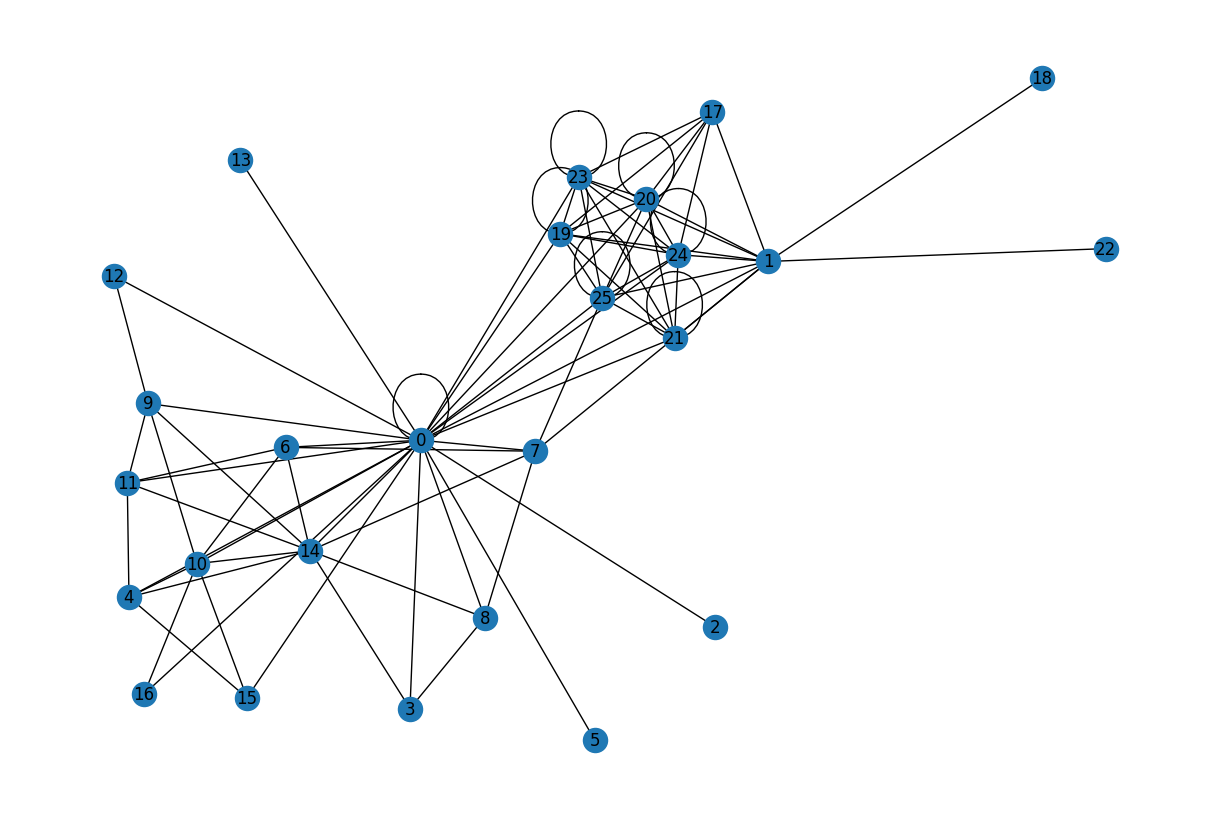

In [43]:
plt.figure(figsize=(12,8))
nx.draw(g, with_labels=True)
plt.show()

Diameter

The diameter of a web graph refers to the maximum shortest path between any two nodes (webpages) in the graph representing the web's hyperlink structure.

In [44]:
print(nx.diameter(g))

3


The diameter of this web graph is 3. The low diameter reflects fast information spread, efficient navigation, and the interconnectedness of the web graph

Density

The density of a web graph refers to how many edges (hyperlinks) exist compared to the maximum possible number of edges, 
given the number of nodes (web pages) in the graph.

Density helps analysts determine how "connected" or "sparse" the web graph is, which affects algorithms for crawling, ranking,
or clustering pages.

Low density indicates fewer connections relative to possible links; high density suggests a highly interconnected website or web subset.

In [45]:
# density
density = nx.density(g)
print(density)

0.24923076923076923


With a density of 0.2493, means that the graph contains about 24.93% of all possible edges between nodes, indicating a moderately connected network—neither sparse nor fully connected.

Centrality

The centrality of a web graph refers to measures that identify the most important or influential nodes (such as web pages or sites) within the overall network structure of the web graph. Centrality helps highlight which nodes have significant roles in connectivity, information flow, and influence throughout the network

In [46]:
#degree centrality
dc = nx.degree_centrality(g)

for k in dc.keys():
    print(f"{str(k).ljust(4)} ---- {dc[k]}")

0    ---- 0.96
1    ---- 0.44
2    ---- 0.04
3    ---- 0.12
4    ---- 0.2
5    ---- 0.04
6    ---- 0.2
7    ---- 0.24
8    ---- 0.16
9    ---- 0.2
10   ---- 0.28
11   ---- 0.2
12   ---- 0.08
13   ---- 0.04
14   ---- 0.36
15   ---- 0.12
16   ---- 0.08
17   ---- 0.24
18   ---- 0.04
19   ---- 0.4
20   ---- 0.4
21   ---- 0.36
22   ---- 0.04
23   ---- 0.4
24   ---- 0.4
25   ---- 0.44


In [47]:
# Highest degree centrality
print(max(dc, key=dc.get), dc[max(dc, key=dc.get)])

0 0.96




Node 0, has the highest degree centrality, meaning it has a significant roles in connectivity, information flow, and influence throughout the network or maybe it is because it is the "home" page of the website.

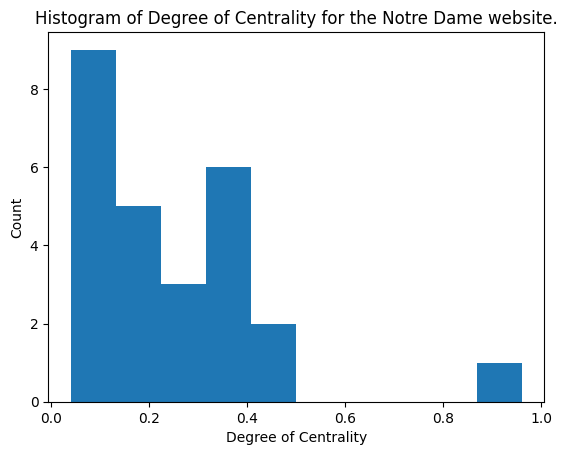

In [48]:
plt.hist(dc.values())
plt.title("Histogram of Degree of Centrality for the Notre Dame website.")
plt.xlabel("Degree of Centrality")
plt.ylabel("Count")
plt.show()

Traversal of a web graph refers to the systematic process of visiting nodes (web pages) and edges (links between pages) in a graph representing the World Wide Web. The goal is to explore and collect information about web pages by following the directed links from one page to another.

We will use DFS.  Depth-First Search (DFS): Explores as far as possible along each branch before backtracking. It is typically implemented with a stack or recursion and is useful for tasks like detecting cycles and connected components.

In [49]:
from networkx.algorithms import traversal

In [50]:
def DFS_nodes(graph, node, visited=[]):
    visited.append(node)
    for neighbor in graph[node]:
        
        if not neighbor in visited:
            DFS_nodes(graph, neighbor, visited)

    return visited

In [51]:
def DFS_edges(graph,node,visited=[], edges=[]):
    visited.append(node)
    for ni in graph[node]:
        
        if not ni in visited:
            edges.append((node,ni))
            DFS_edges(graph,ni,visited,edges)

    return edges

In [52]:
dfs_order = DFS_nodes(g,0)

In [53]:
edges = traversal.dfs_edges(g)
edges

<generator object dfs_edges at 0x118812260>

In [54]:
tree = traversal.dfs_tree(g)
tree

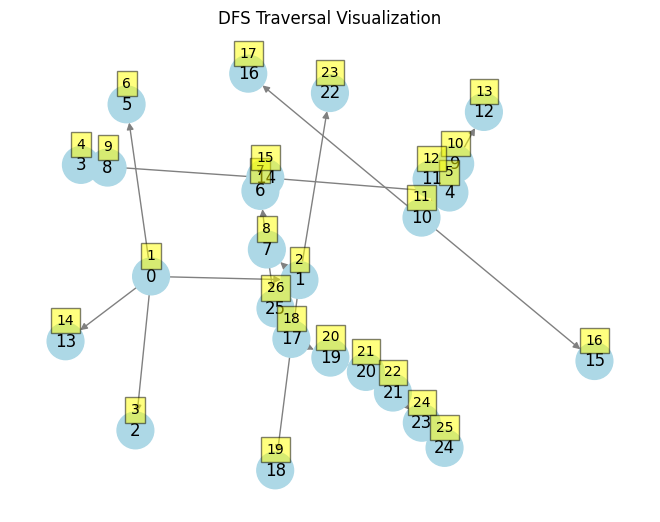

In [55]:
pos = nx.spring_layout(tree, seed=42)
node_colors = ['lightblue' if n in dfs_order else 'grey' for n in tree.nodes()]
nx.draw(tree, pos, with_labels=True, node_color=node_colors, node_size=700, edge_color='gray')

# Annotate traversal order
for idx, node in enumerate(tree):
    plt.text(pos[node][0], pos[node][1]+0.08, s=str(idx+1), bbox=dict(facecolor='yellow', alpha=0.5), ha='center')

plt.title("DFS Traversal Visualization")
plt.show()